# Eye Tracking( Metric Extraction & Model Training)

In [61]:
import cv2
print(cv2.__version__)  # to verify installation

4.13.0


In [62]:
import os
# from google.colab import drive
# drive.mount('/content/drive')

TRAIN_DIR  = 'Autism emotion dataset/train'
TEST_DIR   = 'Autism emotion dataset/test'
OUTPUT_DIR = 'Autism emotion recognition dataset/results/Eye'

EYE_CSV          = os.path.join(OUTPUT_DIR, 'eye_metrics.csv')
EYE_TEST_CSV     = os.path.join(OUTPUT_DIR, 'eye_metrics_test.csv')
MODELS_DIR  = os.path.join(OUTPUT_DIR, 'Eye_models')


os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Train   : {TRAIN_DIR}')
print(f'Test    : {TEST_DIR}')
print(f'CSV     : {EYE_CSV}')
print(f'Models  : {MODELS_DIR}')

Train   : Autism emotion dataset/train
Test    : Autism emotion dataset/test
CSV     : Autism emotion recognition dataset/results/Eye/eye_metrics.csv
Models  : Autism emotion recognition dataset/results/Eye/Eye_models


In [ ]:
import cv2
import json
import shutil
import joblib
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install mediapipe
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
)
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier


# ── Constants
EMOTIONS    = ['anger', 'fear', 'joy', 'natural', 'sadness', 'surprise']
EMOTION_IDX = {e: i for i, e in enumerate(EMOTIONS)}
IDX_EMOTION = {i: e for e, i in EMOTION_IDX.items()}
GAZE_DIRS   = ['centre', 'left', 'right', 'up', 'down']

# MediaPipe landmark indices
LEFT_EYE_INDICES   = [33, 7, 163, 144, 145, 153, 154, 155, 133, 173, 157, 158, 159, 160, 161, 246]
RIGHT_EYE_INDICES  = [362, 382, 381, 380, 374, 373, 390, 249, 263, 466, 388, 387, 386, 385, 384, 398]
LEFT_EYE_VERTICAL_1  = [159, 145]; LEFT_EYE_VERTICAL_2  = [158, 153]; LEFT_EYE_HORIZONTAL  = [33, 133]
RIGHT_EYE_VERTICAL_1 = [386, 374]; RIGHT_EYE_VERTICAL_2 = [385, 380]; RIGHT_EYE_HORIZONTAL = [362, 263]
LEFT_IRIS_INDICES  = [468, 469, 470, 471, 472]
RIGHT_IRIS_INDICES = [473, 474, 475, 476, 477]

# Base features extracted from MediaPipe
STATIC_FEATURES = [
    'left_ear', 'right_ear', 'avg_ear', 'eye_openness_pct',
    'left_relative_pupil_x', 'left_relative_pupil_y',
    'right_relative_pupil_x', 'right_relative_pupil_y',
    'left_eye_width', 'left_eye_height',
    'right_eye_width', 'right_eye_height',
]

print(f'Base features  : {len(STATIC_FEATURES)}')

  Obtaining dependency information for mediapipe from https://files.pythonhosted.org/packages/7b/bc/0695a2af4e35a8cbeaf0957eb2342acc1541ab363f36e8b51018193e05df/mediapipe-0.10.33-py3-none-manylinux_2_28_x86_64.whl.metadata
  Using cached mediapipe-0.10.33-py3-none-manylinux_2_28_x86_64.whl.metadata (9.8 kB)
  Obtaining dependency information for absl-py~=2.3 from https://files.pythonhosted.org/packages/18/a6/907a406bb7d359e6a63f99c313846d9eec4f7e6f7437809e03aa00fa3074/absl_py-2.4.0-py3-none-any.whl.metadata
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Obtaining dependency information for numpy from https://files.pythonhosted.org/packages/0a/0d/0e3ecece05b7a7e87ab9fb587855548da437a061326fff64a223b6dcb78a/numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Obtaining dependency information for sounddevice~=0.5 from https://files.pytho

## Functions (MediaPipe)

In [64]:
def calculate_distance(p1, p2):
    return np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

def calculate_eye_aspect_ratio(v1, v2, h):
    """EAR = (|V1| + |V2|) / (2*|H|). Open ≈ 0.25-0.35, blink < 0.20"""
    return (calculate_distance(*v1) + calculate_distance(*v2)) / (2.0 * calculate_distance(*h) + 1e-6)

def get_eye_metrics(landmarks, image_width, image_height,
                    eye_indices, v1_idx, v2_idx, h_idx, iris_indices=None):
    pts = np.array([(int(landmarks[i].x*image_width), int(landmarks[i].y*image_height))
                    for i in eye_indices])
    eye_left, eye_right = int(pts[:,0].min()), int(pts[:,0].max())
    eye_top,  eye_bottom = int(pts[:,1].min()), int(pts[:,1].max())
    eye_width    = eye_right - eye_left
    eye_height   = eye_bottom - eye_top
    eye_center_x = (eye_left + eye_right) / 2
    eye_center_y = (eye_top  + eye_bottom) / 2

    def lm(i): return (landmarks[i].x*image_width, landmarks[i].y*image_height)
    v1  = [lm(v1_idx[0]), lm(v1_idx[1])]
    v2  = [lm(v2_idx[0]), lm(v2_idx[1])]
    h   = [lm(h_idx[0]),  lm(h_idx[1])]
    ear = calculate_eye_aspect_ratio(v1, v2, h)

    pupil_x, pupil_y = eye_center_x, eye_center_y
    if iris_indices and len(landmarks) > max(iris_indices):
        pupil_x = landmarks[iris_indices[0]].x * image_width
        pupil_y = landmarks[iris_indices[0]].y * image_height

    return {
        'pupil_x': pupil_x, 'pupil_y': pupil_y,
        'relative_pupil_x': (pupil_x - eye_center_x) / (eye_width  / 2 + 1e-6),
        'relative_pupil_y': (pupil_y - eye_center_y) / (eye_height / 2 + 1e-6),
        'eye_center_x': eye_center_x, 'eye_center_y': eye_center_y,
        'eye_width': eye_width, 'eye_height': eye_height,
        'eye_aspect_ratio': ear,
        'eye_bbox': (eye_left, eye_top, eye_right, eye_bottom),
    }

def derive_gaze_direction(left_m, right_m):
    avg_x = (left_m['relative_pupil_x'] + right_m['relative_pupil_x']) / 2
    avg_y = (left_m['relative_pupil_y'] + right_m['relative_pupil_y']) / 2
    if abs(avg_x) < 0.15 and abs(avg_y) < 0.15: return 'centre'
    if abs(avg_x) >= abs(avg_y): return 'right' if avg_x > 0 else 'left'
    return 'down' if avg_y > 0 else 'up'

print('functions defined.')

functions defined.


## Download MediaPipe Model

In [65]:
MODEL_PATH = 'face_landmarker.task'
if not os.path.exists(MODEL_PATH):
    print('Downloading face_landmarker.task...')
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task',
        MODEL_PATH
    )
    print('Done')
else:
    print('face_landmarker.task already present.')

face_landmarker.task already present.


In [ ]:

def extract_eye_metrics(dataset_path, output_csv):
    """Run MediaPipe on all images, extract eye metrics, save to CSV."""
    options  = vision.FaceLandmarkerOptions(
        base_options=python.BaseOptions(model_asset_path=MODEL_PATH),
        output_face_blendshapes=False,
        output_facial_transformation_matrixes=False,
        num_faces=1
    )
    detector = vision.FaceLandmarker.create_from_options(options)
    print('MediaPipe Face Landmarker initialised.')

    all_results = []
    ext = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
    subfolders = [f for f in os.listdir(dataset_path)
                  if os.path.isdir(os.path.join(dataset_path, f))]
    print(f'Found {len(subfolders)} emotion folders: {subfolders}')

    total, processed, failed = 0, 0, 0

    for label in subfolders:
        folder = os.path.join(dataset_path, label)
        files  = [f for f in os.listdir(folder) if os.path.splitext(f.lower())[1] in ext]
        print(f"\n── '{label}': {len(files)} images")
        total += len(files)

        for idx, fname in enumerate(files):
            img = cv2.imread(os.path.join(folder, fname))
            if img is None:
                print(f'   Cannot read {fname}'); failed += 1; continue

            rgb    = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w   = img.shape[:2]
            result = detector.detect(mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb))

            if result.face_landmarks:
                lm  = result.face_landmarks[0]
                lm_ = get_eye_metrics(lm, w, h, LEFT_EYE_INDICES,
                                      LEFT_EYE_VERTICAL_1, LEFT_EYE_VERTICAL_2,
                                      LEFT_EYE_HORIZONTAL, LEFT_IRIS_INDICES)
                rm_ = get_eye_metrics(lm, w, h, RIGHT_EYE_INDICES,
                                      RIGHT_EYE_VERTICAL_1, RIGHT_EYE_VERTICAL_2,
                                      RIGHT_EYE_HORIZONTAL, RIGHT_IRIS_INDICES)
                avg_ear = (lm_['eye_aspect_ratio'] + rm_['eye_aspect_ratio']) / 2

                all_results.append({
                    'label': label.lower(), 'image_file':f"{label}_{fname}",
                    'image_width': w, 'image_height': h,
                    'left_pupil_x':           lm_['pupil_x'],
                    'left_pupil_y':           lm_['pupil_y'],
                    'left_relative_pupil_x':  lm_['relative_pupil_x'],
                    'left_relative_pupil_y':  lm_['relative_pupil_y'],
                    'left_eye_center_x':      lm_['eye_center_x'],
                    'left_eye_center_y':      lm_['eye_center_y'],
                    'left_eye_width':         lm_['eye_width'],
                    'left_eye_height':        lm_['eye_height'],
                    'left_ear':               lm_['eye_aspect_ratio'],
                    'right_pupil_x':          rm_['pupil_x'],
                    'right_pupil_y':          rm_['pupil_y'],
                    'right_relative_pupil_x': rm_['relative_pupil_x'],
                    'right_relative_pupil_y': rm_['relative_pupil_y'],
                    'right_eye_center_x':     rm_['eye_center_x'],
                    'right_eye_center_y':     rm_['eye_center_y'],
                    'right_eye_width':        rm_['eye_width'],
                    'right_eye_height':       rm_['eye_height'],
                    'right_ear':              rm_['eye_aspect_ratio'],
                    'avg_ear':          avg_ear,
                    'eye_openness_pct': min(100.0, (avg_ear / 0.30) * 100),
                    'gaze_direction':   derive_gaze_direction(lm_, rm_),
                })
                processed += 1
            else:
                failed += 1

            if (idx+1) % 50 == 0 or (idx+1) == len(files):
                print(f'  {idx+1}/{len(files)} done')

    detector.close()
    df = pd.DataFrame(all_results)
    df.to_csv(output_csv, index=False)
    print(f'\n Saved: {output_csv}')
    print(f'  Total: {total}  |  Processed: {processed}  |  Failed/No face: {failed}')
    print(df['label'].value_counts().sort_index().to_string())
    return df


df = extract_eye_metrics(TRAIN_DIR, EYE_CSV)

MediaPipe Face Landmarker initialised.
Found 6 emotion folders: ['anger', 'fear', 'joy', 'Natural', 'sadness', 'surprise']

── 'anger': 200 images


W0000 00:00:1775493616.852892 3974037 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1775493616.858815 3974037 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1775493616.910255 3974100 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 590.44.01), renderer: Quadro RTX 6000/PCIe/SSE2
W0000 00:00:1775493616.913624 3974052 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775493616.928113 3974077 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


  50/200 done
  100/200 done
  150/200 done
  200/200 done

── 'fear': 200 images
  50/200 done
  100/200 done
  150/200 done
  200/200 done

── 'joy': 200 images
  50/200 done
  100/200 done
  150/200 done
  200/200 done

── 'Natural': 200 images
  50/200 done
  100/200 done
  150/200 done
  200/200 done

── 'sadness': 199 images
  50/199 done
  100/199 done
  150/199 done
  199/199 done

── 'surprise': 200 images
  50/200 done
  100/200 done
  150/200 done
  200/200 done

✓ Saved: Autism emotion recognition dataset/results/Eye/eye_metrics.csv
  Total: 1199  |  Processed: 1040  |  Failed/No face: 159
label
anger       167
fear        171
joy         200
natural     170
sadness     169
surprise    163


## Exploratory Data Analysis

In [67]:
df = pd.read_csv(EYE_CSV)
print(f'Samples : {len(df)}')
print(df['label'].value_counts().sort_index())
df.head(5)

Samples : 1040
label
anger       167
fear        171
joy         200
natural     170
sadness     169
surprise    163
Name: count, dtype: int64


,label,image_file,image_width,image_height,left_pupil_x,left_pupil_y,left_relative_pupil_x,left_relative_pupil_y,left_eye_center_x,left_eye_center_y,...,right_relative_pupil_x,right_relative_pupil_y,right_eye_center_x,right_eye_center_y,right_eye_width,right_eye_height,right_ear,avg_ear,eye_openness_pct,gaze_direction
0,anger,anger_1 (1).jpg,224,224,62.951855,122.069857,0.121991,-0.408612,61.0,123.5,...,0.164153,-0.490828,143.0,124.5,40,7,0.192806,0.207798,69.266137,up
1,anger,anger_1 (10).jpg,224,224,50.716995,124.188984,0.059366,-0.441469,49.5,127.5,...,0.115912,-0.323332,134.5,114.5,41,19,0.366093,0.376250,100.000000,up
2,anger,anger_1 (100).jpg,224,224,56.678981,116.867188,0.056582,-0.180804,56.0,117.5,...,0.208314,0.096067,117.5,124.5,27,7,0.227640,0.244839,81.613078,centre
3,anger,anger_1 (101).jpg,224,224,102.386108,114.795645,-0.124145,0.118258,104.0,114.5,...,0.018063,-0.010111,166.0,112.0,24,6,0.222310,0.214916,71.638645,centre
4,anger,anger_1 (102).jpg,224,224,60.622616,107.562756,0.146387,-0.087449,58.5,108.0,...,0.197128,-0.043733,137.5,118.5,35,9,0.247831,0.264007,88.002496,right


/tmp/ipykernel_2932942/1011232748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='avg_ear', order=EMOTIONS, palette='Set2', ax=axes[0])
/tmp/ipykernel_2932942/1011232748.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='eye_openness_pct', order=EMOTIONS, palette='pastel', ax=axes[1])


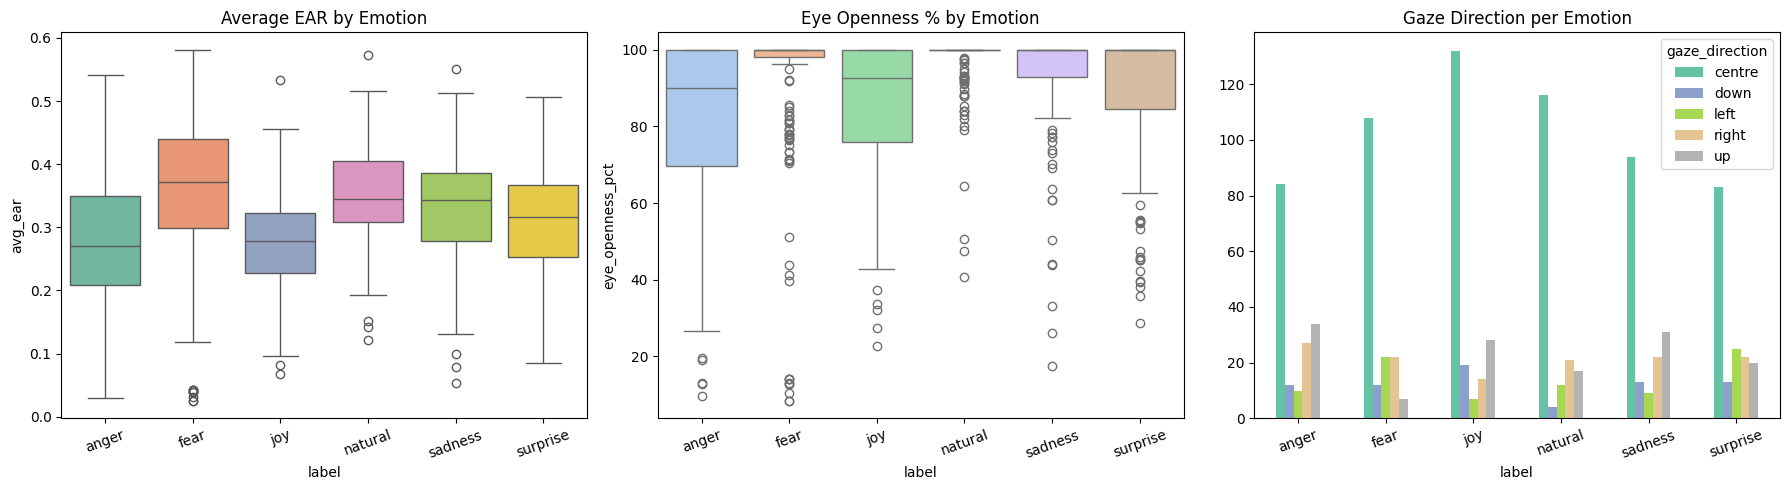

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='label', y='avg_ear', order=EMOTIONS, palette='Set2', ax=axes[0])
axes[0].set_title('Average EAR by Emotion')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='label', y='eye_openness_pct', order=EMOTIONS, palette='pastel', ax=axes[1])
axes[1].set_title('Eye Openness % by Emotion')
axes[1].tick_params(axis='x', rotation=20)

gaze_pivot = df.groupby(['label','gaze_direction']).size().unstack(fill_value=0)
gaze_pivot.plot(kind='bar', ax=axes[2], colormap='Set2', legend=True)
axes[2].set_title('Gaze Direction per Emotion')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_plots.png'), dpi=150)
plt.show()

In [ ]:
def engineer_features(df):
    """Build a rich feature dataframe from raw eye metrics."""
    f = df.copy()

    # ── 1. Gaze one-hot encoding ───────────────────────────────
    gaze_dummies = pd.get_dummies(f['gaze_direction'], prefix='gaze')
    for d in GAZE_DIRS:
        col = f'gaze_{d}'
        if col not in gaze_dummies:
            gaze_dummies[col] = 0
    gaze_dummies = gaze_dummies[[f'gaze_{d}' for d in GAZE_DIRS]]

    # ── 2. EAR asymmetry (left vs right) ──────────────────────
    # Emotions like fear/surprise often create asymmetric eye opening
    f['ear_asymmetry']        = f['left_ear'] - f['right_ear']
    f['ear_asymmetry_abs']    = f['ear_asymmetry'].abs()
    f['ear_ratio_lr']         = f['left_ear'] / (f['right_ear'] + 1e-6)

    #  3. Eye shape features 
    # Aspect ratio of each eye (height/width) — squinting vs wide
    f['left_eye_aspect']      = f['left_eye_height']  / (f['left_eye_width']  + 1e-6)
    f['right_eye_aspect']     = f['right_eye_height'] / (f['right_eye_width'] + 1e-6)
    f['eye_aspect_asymmetry'] = f['left_eye_aspect']  - f['right_eye_aspect']

    # Eye width asymmetry — one eye pulled wider
    f['eye_width_asymmetry']  = f['left_eye_width']  - f['right_eye_width']
    f['eye_height_asymmetry'] = f['left_eye_height'] - f['right_eye_height']

    #  4. Pupil displacement features
    # Average gaze vector magnitude — how far off centre is the gaze
    f['avg_gaze_x']           = (f['left_relative_pupil_x'] + f['right_relative_pupil_x']) / 2
    f['avg_gaze_y']           = (f['left_relative_pupil_y'] + f['right_relative_pupil_y']) / 2
    f['gaze_magnitude']       = np.sqrt(f['avg_gaze_x']**2 + f['avg_gaze_y']**2)

    # Pupil divergence between eyes
    f['pupil_x_divergence']   = f['left_relative_pupil_x'] - f['right_relative_pupil_x']
    f['pupil_y_divergence']   = f['left_relative_pupil_y'] - f['right_relative_pupil_y']

    #  5. EAR × gaze interaction
    # Wide eyes + upward gaze = surprise; narrowed + sideways = suspicion
    f['ear_x_gaze_mag']       = f['avg_ear'] * f['gaze_magnitude']
    f['ear_x_gaze_y']         = f['avg_ear'] * f['avg_gaze_y']

    #  6. Blink proxy
    f['is_wide_open']         = (f['avg_ear'] > 0.30).astype(int)
    f['is_squinting']         = (f['avg_ear'] < 0.22).astype(int)

    # Combine all features
    engineered_cols = [
        'ear_asymmetry', 'ear_asymmetry_abs', 'ear_ratio_lr',
        'left_eye_aspect', 'right_eye_aspect', 'eye_aspect_asymmetry',
        'eye_width_asymmetry', 'eye_height_asymmetry',
        'avg_gaze_x', 'avg_gaze_y', 'gaze_magnitude',
        'pupil_x_divergence', 'pupil_y_divergence',
        'ear_x_gaze_mag', 'ear_x_gaze_y',
        'is_wide_open', 'is_squinting',
    ]

    feature_df = pd.concat([
        f[STATIC_FEATURES].fillna(0).reset_index(drop=True),
        f[engineered_cols].fillna(0).reset_index(drop=True),
        gaze_dummies.reset_index(drop=True),
    ], axis=1)

    return feature_df


feature_df = engineer_features(df)
print(f'Total features after engineering: {feature_df.shape[1]}')
print(f'Feature names: {list(feature_df.columns)}')

Total features after engineering: 34
Feature names: ['left_ear', 'right_ear', 'avg_ear', 'eye_openness_pct', 'left_relative_pupil_x', 'left_relative_pupil_y', 'right_relative_pupil_x', 'right_relative_pupil_y', 'left_eye_width', 'left_eye_height', 'right_eye_width', 'right_eye_height', 'ear_asymmetry', 'ear_asymmetry_abs', 'ear_ratio_lr', 'left_eye_aspect', 'right_eye_aspect', 'eye_aspect_asymmetry', 'eye_width_asymmetry', 'eye_height_asymmetry', 'avg_gaze_x', 'avg_gaze_y', 'gaze_magnitude', 'pupil_x_divergence', 'pupil_y_divergence', 'ear_x_gaze_mag', 'ear_x_gaze_y', 'is_wide_open', 'is_squinting', 'gaze_centre', 'gaze_left', 'gaze_right', 'gaze_up', 'gaze_down']


In [ ]:
# ── Build X, y  (train split only — test set loaded separately below)
X = feature_df.values.astype(np.float32)
y = np.array([EMOTION_IDX.get(lbl, 0) for lbl in df['label']])

# 80 / 20  train / val  split   (stratified to maintain class balance)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scaler for SVM (tree models don't need it)
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)

INPUT_DIM = X_train.shape[1]
print(f'Feature dim : {INPUT_DIM}')
print(f'Train       : {len(X_train)}')
print(f'Val         : {len(X_val)}')

#  Extract features from held-out test split and save to CSV (if not already done)
print('\n── Extracting eye metrics from TEST_DIR ...')
extract_eye_metrics(TEST_DIR, EYE_TEST_CSV)

df_test      = pd.read_csv(EYE_TEST_CSV)
feature_test = engineer_features(df_test)
X_test       = feature_test.values.astype(np.float32)
y_test       = np.array([EMOTION_IDX.get(lbl, 0) for lbl in df_test['label']])
X_test_sc    = scaler.transform(X_test)   # use scaler fitted on train only

print(f'Test        : {len(X_test)}')

# ── Cross-validation setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results   = {}
cv_scores = {}

Feature dim : 34
Train       : 832
Val         : 208

── Extracting eye metrics from TEST_DIR ...
MediaPipe Face Landmarker initialised.
Found 6 emotion folders: ['anger', 'fear', 'joy', 'Natural', 'sadness', 'surprise']

── 'anger': 40 images


W0000 00:00:1775493637.715843 4012347 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1775493637.721426 4012347 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1775493637.803885 4012392 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 590.44.01), renderer: Quadro RTX 6000/PCIe/SSE2
W0000 00:00:1775493637.807020 4012357 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775493637.820632 4012377 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


  40/40 done

── 'fear': 36 images
  36/36 done

── 'joy': 35 images
  35/35 done

── 'Natural': 40 images
  40/40 done

── 'sadness': 38 images
  38/38 done

── 'surprise': 37 images
  37/37 done

✓ Saved: Autism emotion recognition dataset/results/Eye/eye_metrics_test.csv
  Total: 226  |  Processed: 173  |  Failed/No face: 53
label
anger       30
fear        28
joy         24
natural     31
sadness     33
surprise    27
Test        : 173


In [71]:
def eval_sklearn(name, model, X_tr, y_tr, X_v, y_v, save_path, use_pipeline=False, X_te=None, y_te=None):
    """
    Fit, cross-validate, evaluate on val and held-out test set, save an sklearn model.
    use_pipeline=True wraps model in StandardScaler pipeline (for SVM).
    """
    print('\n' + '=' * 55)
    print(f'  {name}')
    print('=' * 55)

    if use_pipeline:
        clf = Pipeline([('scaler', StandardScaler()), ('model', model)])
        cv_X, cv_y = X_train, y_train   # pipeline scales internally
    else:
        clf = model
        cv_X, cv_y = X_tr, y_tr

    # Cross-validation on training set
    cv = cross_val_score(clf, cv_X, cv_y, cv=skf, scoring='accuracy', n_jobs=-1)
    print(f'  CV  Accuracy : {cv.mean():.4f} +- {cv.std():.4f}')
    cv_scores[name] = cv.mean()

    # Final fit and val evaluation
    clf.fit(X_tr, y_tr)
    preds = clf.predict(X_v)
    acc   = accuracy_score(y_v, preds)
    results[name] = acc

    joblib.dump(clf, save_path)
    print(f'  Val Accuracy : {acc:.4f}')
    print(classification_report(y_v, preds, target_names=EMOTIONS, zero_division=0))

    # ── Held-out test evaluation ──────────────────────────────
    if X_te is not None and y_te is not None:
        test_preds = clf.predict(X_te)
        test_acc   = accuracy_score(y_te, test_preds)
        print(f'  Test Accuracy: {test_acc:.4f}')
        print(classification_report(y_te, test_preds, target_names=EMOTIONS, zero_division=0))
        return clf, acc, test_acc

    return clf, acc, None

print('eval_sklearn function defined.')


eval_sklearn function defined.


In [ ]:
# ── Random Forest 
rf_model, _, rf_test_acc = eval_sklearn(
    'Random Forest',
    RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    X_train, y_train, X_val, y_val,
    os.path.join(MODELS_DIR, 'eye_rf.pkl'),
    X_te=X_test, y_te=y_test
)



  Random Forest
  CV  Accuracy : 0.4663 +- 0.0385
  Val Accuracy : 0.4808
              precision    recall  f1-score   support

       anger       0.47      0.42      0.44        33
        fear       0.74      0.74      0.74        34
         joy       0.52      0.57      0.55        40
     natural       0.38      0.53      0.44        34
     sadness       0.38      0.32      0.35        34
    surprise       0.38      0.27      0.32        33

    accuracy                           0.48       208
   macro avg       0.48      0.48      0.47       208
weighted avg       0.48      0.48      0.48       208

  Test Accuracy: 0.1965
              precision    recall  f1-score   support

       anger       0.30      0.27      0.28        30
        fear       0.40      0.29      0.33        28
         joy       0.24      0.50      0.32        24
     natural       0.05      0.06      0.05        31
     sadness       0.12      0.06      0.08        33
    surprise       0.11      0.07

In [73]:
# ── XGBoost
xgb_model, _, xgb_model_test_acc = eval_sklearn(
    'XGBoost',
    XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        gamma=0.1,
        eval_metric='mlogloss',
        random_state=42, verbosity=0
    ),
    X_train, y_train, X_val, y_val,
    os.path.join(MODELS_DIR, 'eye_xgb.pkl')
,
    X_te=X_test, y_te=y_test
)



  XGBoost
  CV  Accuracy : 0.4507 +- 0.0403
  Val Accuracy : 0.3894
              precision    recall  f1-score   support

       anger       0.33      0.30      0.32        33
        fear       0.56      0.59      0.57        34
         joy       0.51      0.53      0.52        40
     natural       0.31      0.32      0.31        34
     sadness       0.34      0.38      0.36        34
    surprise       0.22      0.18      0.20        33

    accuracy                           0.39       208
   macro avg       0.38      0.38      0.38       208
weighted avg       0.38      0.39      0.39       208

  Test Accuracy: 0.1734
              precision    recall  f1-score   support

       anger       0.30      0.20      0.24        30
        fear       0.48      0.36      0.41        28
         joy       0.19      0.38      0.25        24
     natural       0.05      0.06      0.06        31
     sadness       0.05      0.03      0.04        33
    surprise       0.08      0.07      

In [74]:
# ── SVM (needs scaled data, wrapped in pipeline) ──────────────
svm_model, _, svm_model_test_acc = eval_sklearn(
    'SVM',
    SVC(kernel='rbf', C=10, gamma='scale', probability=True, class_weight='balanced', random_state=42),
    X_tr_sc, y_train, X_val_sc, y_val,
    os.path.join(MODELS_DIR, 'eye_svm.pkl'),
    use_pipeline=False,   # already passing scaled data
    X_te=X_test_sc, y_te=y_test
)
# Save scaler separately for SVM inference
joblib.dump(scaler, os.path.join(MODELS_DIR, 'eye_svm_scaler.pkl'))
print('SVM scaler saved.')



  SVM
  CV  Accuracy : 0.4087 +- 0.0160
  Val Accuracy : 0.3990
              precision    recall  f1-score   support

       anger       0.34      0.36      0.35        33
        fear       0.61      0.56      0.58        34
         joy       0.47      0.45      0.46        40
     natural       0.35      0.53      0.42        34
     sadness       0.29      0.24      0.26        34
    surprise       0.32      0.24      0.28        33

    accuracy                           0.40       208
   macro avg       0.40      0.40      0.39       208
weighted avg       0.40      0.40      0.40       208

  Test Accuracy: 0.2081
              precision    recall  f1-score   support

       anger       0.17      0.13      0.15        30
        fear       0.40      0.36      0.38        28
         joy       0.33      0.54      0.41        24
     natural       0.12      0.19      0.15        31
     sadness       0.12      0.06      0.08        33
    surprise       0.05      0.04      0.04

In [ ]:
# -- Voting Ensemble ---------------------------------------------
# Combines Random Forest and XGBoost using soft voting.
print('\n' + '='*55)
print('  Voting Ensemble (RF + XGB)')
print('='*55)

voting_clf = VotingClassifier(
    estimators=[
        ('rf',   RandomForestClassifier(n_estimators=500, min_samples_leaf=2,
                                        max_features='sqrt', class_weight='balanced',
                                        random_state=42, n_jobs=-1)),
        ('xgb',  XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8,
                               eval_metric='mlogloss', random_state=42, verbosity=0)),
    ],
    voting='soft',
    n_jobs=-1
)

cv = cross_val_score(voting_clf, X_train, y_train, cv=skf, scoring='accuracy', n_jobs=-1)
print(f'  CV  Accuracy : {cv.mean():.4f} +- {cv.std():.4f}')
cv_scores['Voting Ensemble'] = cv.mean()

voting_clf.fit(X_train, y_train)
preds = voting_clf.predict(X_val)
acc   = accuracy_score(y_val, preds)
results['Voting Ensemble'] = acc

joblib.dump(voting_clf, os.path.join(MODELS_DIR, 'eye_voting.pkl'))
print(f'  Val Accuracy : {acc:.4f}')
print(classification_report(y_val, preds, target_names=EMOTIONS, zero_division=0))

# ── Test evaluation for Voting Ensemble 
voting_test_preds = voting_clf.predict(X_test)
voting_test_acc   = accuracy_score(y_test, voting_test_preds)
print(f'  Test Accuracy (Voting Ensemble): {voting_test_acc:.4f}')
print(classification_report(y_test, voting_test_preds, target_names=EMOTIONS, zero_division=0))



  Voting Ensemble (RF + XGB)
  CV  Accuracy : 0.4627 +- 0.0470
  Val Accuracy : 0.4423
              precision    recall  f1-score   support

       anger       0.41      0.33      0.37        33
        fear       0.68      0.68      0.68        34
         joy       0.52      0.55      0.54        40
     natural       0.35      0.44      0.39        34
     sadness       0.34      0.35      0.35        34
    surprise       0.33      0.27      0.30        33

    accuracy                           0.44       208
   macro avg       0.44      0.44      0.44       208
weighted avg       0.44      0.44      0.44       208

  Test Accuracy (Voting Ensemble): 0.1850
              precision    recall  f1-score   support

       anger       0.29      0.23      0.26        30
        fear       0.45      0.32      0.38        28
         joy       0.25      0.50      0.33        24
     natural       0.05      0.06      0.05        31
     sadness       0.00      0.00      0.00        33
  

In [76]:
# ── Model Comparison Table ────────────────────────────────────
print('\n' + '='*55)
print('MODEL COMPARISON')
print('='*55)
print(f'{"Model":<22}  {"CV Acc":>8}  {"Val Acc":>8}')
print('-'*45)
for name in sorted(results, key=lambda n: -results[n]):
    marker = '  ← BEST' if results[name] == max(results.values()) else ''
    cv_str = f'{cv_scores.get(name, 0):.4f}'
    print(f'  {name:<20}  {cv_str:>8}  {results[name]:.4f}{marker}')

best_model_name = max(results, key=results.get)
print(f'\n✓ Best: {best_model_name}  (val_acc={results[best_model_name]:.4f})')


MODEL COMPARISON
Model                     CV Acc   Val Acc
---------------------------------------------
  Random Forest           0.4663  0.4808  ← BEST
  Voting Ensemble         0.4627  0.4423
  SVM                     0.4087  0.3990
  XGBoost                 0.4507  0.3894

✓ Best: Random Forest  (val_acc=0.4808)


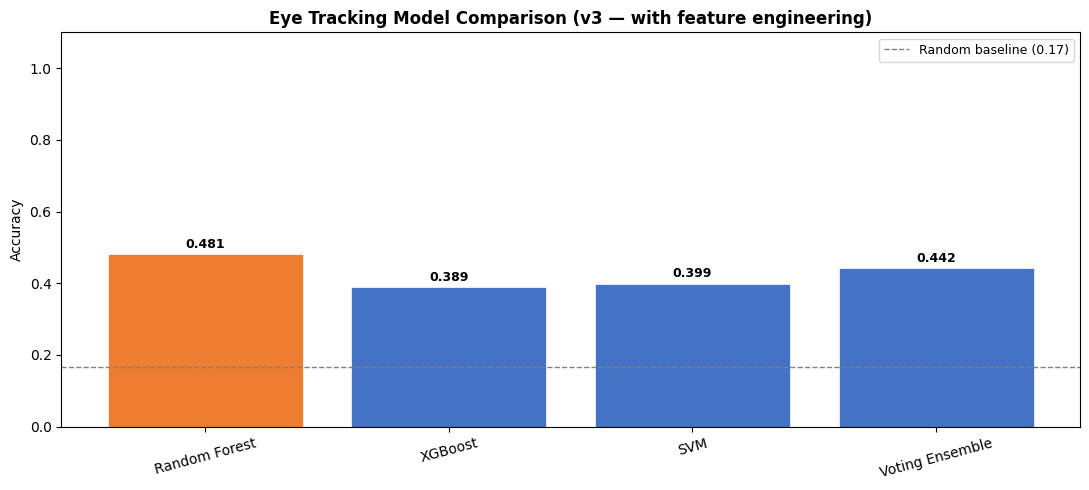

In [77]:
# ── Bar Chart ─────────────────────────────────────────────────
names   = list(results.keys())
accs    = [results[n] for n in names]
colours = ['#ED7D31' if n == best_model_name else '#4472C4' for n in names]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(names, accs, color=colours, edgecolor='white', linewidth=0.5)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('Eye Tracking Model Comparison (v3 — with feature engineering)', fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.axhline(y=1/len(EMOTIONS), color='grey', linestyle='--', linewidth=1,
           label=f'Random baseline ({1/len(EMOTIONS):.2f})')
ax.legend(fontsize=9)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'model_comparison_v3.png'), dpi=150)
plt.show()

gaze_direction    centre      down      left     right        up
label                                                           
anger           0.502994  0.071856  0.059880  0.161677  0.203593
fear            0.631579  0.070175  0.128655  0.128655  0.040936
joy             0.660000  0.095000  0.035000  0.070000  0.140000
natural         0.682353  0.023529  0.070588  0.123529  0.100000
sadness         0.556213  0.076923  0.053254  0.130178  0.183432
surprise        0.509202  0.079755  0.153374  0.134969  0.122699


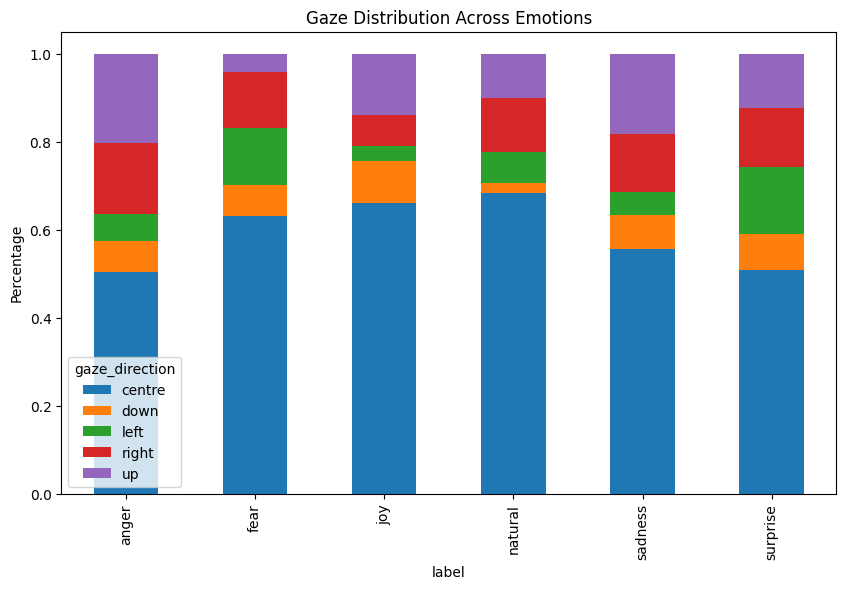

In [78]:
gaze_dist = df.groupby(['label', 'gaze_direction']).size().unstack(fill_value=0)

# Normalize to percentages
gaze_dist_pct = gaze_dist.div(gaze_dist.sum(axis=1), axis=0)

print(gaze_dist_pct)

gaze_dist_pct.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Gaze Distribution Across Emotions')
plt.ylabel('Percentage')
plt.show()

In [79]:
importances = rf_model.feature_importances_
feature_names = feature_df.columns

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feat_imp.head(15))

                   feature  importance
23      pupil_x_divergence    0.048446
2                  avg_ear    0.046468
1                right_ear    0.044461
6   right_relative_pupil_x    0.043765
0                 left_ear    0.043518
10         right_eye_width    0.043045
13       ear_asymmetry_abs    0.042661
20              avg_gaze_x    0.041737
4    left_relative_pupil_x    0.040873
25          ear_x_gaze_mag    0.040075
24      pupil_y_divergence    0.039015
8           left_eye_width    0.038044
15         left_eye_aspect    0.037619
22          gaze_magnitude    0.036222
16        right_eye_aspect    0.036111


In [80]:
from scipy.stats import chi2_contingency

# Contingency table
cont_table = pd.crosstab(df['label'], df['gaze_direction'])
print("Contingency Table:\n", cont_table)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(cont_table)

print(f"\nChi-square Statistic: {chi2:.4f}")
print(f"Degrees of Freedom : {dof}")
print(f"P-value            : {p:.6f}")

# Interpretation
if p < 0.05:
    print("Result: There is a statistically significant relationship between gaze direction and emotion.")
else:
    print("Result: No statistically significant relationship found.")

Contingency Table:
 gaze_direction  centre  down  left  right  up
label                                        
anger               84    12    10     27  34
fear               108    12    22     22   7
joy                132    19     7     14  28
natural            116     4    12     21  17
sadness             94    13     9     22  31
surprise            83    13    25     22  20

Chi-square Statistic: 68.3590
Degrees of Freedom : 20
P-value            : 0.000000
Result: There is a statistically significant relationship between gaze direction and emotion.


In [81]:
from scipy.stats import f_oneway

# Merge engineered features back with labels for statistical testing
analysis_df = pd.concat([df.reset_index(drop=True), feature_df.reset_index(drop=True)], axis=1)

# Group gaze magnitude by emotion
groups = [analysis_df[analysis_df['label'] == e]['gaze_magnitude'] for e in EMOTIONS]

f_stat, p_val = f_oneway(*groups)

print(f"ANOVA Results for gaze_magnitude:")
print(f"F-statistic : {f_stat:.4f}")
print(f"P-value     : {p_val:.6f}")

# Interpretation
if p_val < 0.05:
    print("Result: Significant differences in gaze magnitude across emotions.")
else:
    print("Result: No significant differences in gaze magnitude across emotions.")


ANOVA Results for gaze_magnitude:
F-statistic : 6.4938
P-value     : 0.000006
Result: Significant differences in gaze magnitude across emotions.


In [82]:
for feature in ['avg_gaze_x', 'avg_gaze_y', 'gaze_magnitude']:
    groups = [analysis_df[analysis_df['label'] == e][feature] for e in EMOTIONS]
    f_stat, p_val = f_oneway(*groups)
    print(f"{feature} -> p-value: {p_val:.6f}")


avg_gaze_x -> p-value: 0.059172
avg_gaze_y -> p-value: 0.088025
gaze_magnitude -> p-value: 0.000006


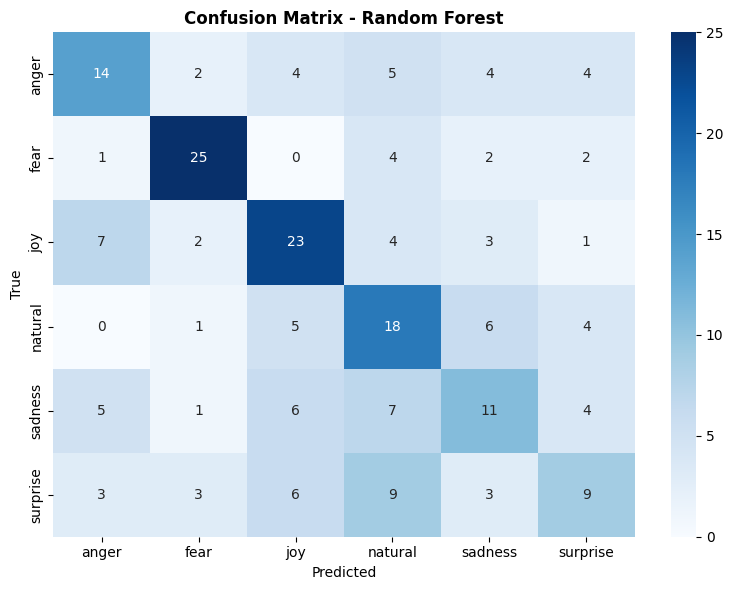

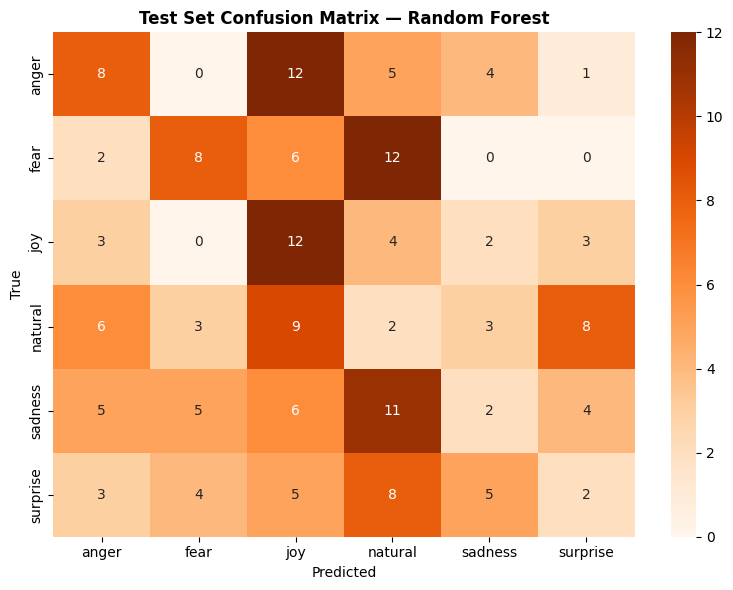


── Test Set Classification Report ──────────────────────
              precision    recall  f1-score   support

       anger       0.30      0.27      0.28        30
        fear       0.40      0.29      0.33        28
         joy       0.24      0.50      0.32        24
     natural       0.05      0.06      0.05        31
     sadness       0.12      0.06      0.08        33
    surprise       0.11      0.07      0.09        27

    accuracy                           0.20       173
   macro avg       0.20      0.21      0.19       173
weighted avg       0.20      0.20      0.19       173

Final Test Accuracy (Random Forest): 0.1965


In [83]:
# -- Confusion Matrix for Best Model -----------------------------
model_files = {
    'Random Forest'  : os.path.join(MODELS_DIR, 'eye_rf.pkl'),
    'XGBoost'        : os.path.join(MODELS_DIR, 'eye_xgb.pkl'),
    'SVM'            : os.path.join(MODELS_DIR, 'eye_svm.pkl'),
    'Voting Ensemble': os.path.join(MODELS_DIR, 'eye_voting.pkl'),
}

best_clf  = joblib.load(model_files[best_model_name])
if best_model_name == 'SVM':
    best_preds = best_clf.predict(X_val_sc)
else:
    best_preds = best_clf.predict(X_val)

cm = confusion_matrix(y_val, best_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=ax)
ax.set_title(f'Confusion Matrix - {best_model_name}', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()


# ── Test set confusion matrix for best model ──────────────────────────────
best_clf_test = joblib.load(model_files[best_model_name])
if best_model_name == 'SVM':
    test_preds_best = best_clf_test.predict(X_test_sc)
else:
    test_preds_best = best_clf_test.predict(X_test)

cm_test = confusion_matrix(y_test, test_preds_best)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=ax)
ax.set_title(f'Test Set Confusion Matrix — {best_model_name}', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix_test.png'), dpi=150)
plt.show()

print('\n── Test Set Classification Report ──────────────────────')
print(classification_report(y_test, test_preds_best, target_names=EMOTIONS, zero_division=0))
test_acc_final = accuracy_score(y_test, test_preds_best)
print(f'Final Test Accuracy ({best_model_name}): {test_acc_final:.4f}')


In [84]:
# ── Copy best model to eye_best.pkl ───────────────────────────
best_src  = model_files[best_model_name]
best_dest = os.path.join(MODELS_DIR, 'eye_best.pkl')
shutil.copy(best_src, best_dest)

# ── Save full config JSON ──────────────────────────────────────
config = {
    'best_model'    : best_model_name,
    'best_val_acc'  : float(results[best_model_name]),
    'best_cv_acc'   : float(cv_scores.get(best_model_name, 0)),
    'input_dim'     : int(INPUT_DIM),
    'num_classes'   : len(EMOTIONS),
    'emotions'      : EMOTIONS,
    'emotion_idx'   : EMOTION_IDX,
    'features'      : list(feature_df.columns),
    'needs_scaler'  : best_model_name == 'SVM',
    'scaler_path'   : 'eye_svm_scaler.pkl' if best_model_name == 'SVM' else None,
    'all_val_results': {k: float(v) for k, v in results.items()},
    'all_cv_results'  : {k: float(v) for k, v in cv_scores.items()},
    'test_accuracy'   : float(test_acc_final),
}
config_path = os.path.join(MODELS_DIR, 'eye_model_config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f'✓ Best model  : {best_model_name}  (val_acc={results[best_model_name]:.4f})')
print(f'✓ Saved to    : {best_dest}')
print(f'✓ Config      : {config_path}')
print(f'\nAll outputs in: {MODELS_DIR}')
print('\n── Files saved ──────────────────────────────────────')
for f in os.listdir(MODELS_DIR):
    print(f'  {f}')

✓ Best model  : Random Forest  (val_acc=0.4808)
✓ Saved to    : Autism emotion recognition dataset/results/Eye/Eye_models/eye_best.pkl
✓ Config      : Autism emotion recognition dataset/results/Eye/Eye_models/eye_model_config.json

All outputs in: Autism emotion recognition dataset/results/Eye/Eye_models

── Files saved ──────────────────────────────────────
  eye_rf.pkl
  eye_xgb.pkl
  eye_svm.pkl
  eye_svm_scaler.pkl
  eye_voting.pkl
  eye_best.pkl
  eye_model_config.json


In [85]:
print("=== TRAIN CSV labels ===")
print(pd.read_csv(EYE_CSV)['label'].value_counts())

print("\n=== TEST CSV labels ===")
print(pd.read_csv(EYE_TEST_CSV)['label'].value_counts())

print("\n=== EMOTION_IDX ===")
print(EMOTION_IDX)

print("\n=== y_test unique values ===")
print(np.unique(y_test, return_counts=True))

print("\n=== y_train unique values ===")
print(np.unique(y_train, return_counts=True))

=== TRAIN CSV labels ===
label
joy         200
fear        171
natural     170
sadness     169
anger       167
surprise    163
Name: count, dtype: int64

=== TEST CSV labels ===
label
sadness     33
natural     31
anger       30
fear        28
surprise    27
joy         24
Name: count, dtype: int64

=== EMOTION_IDX ===
{'anger': 0, 'fear': 1, 'joy': 2, 'natural': 3, 'sadness': 4, 'surprise': 5}

=== y_test unique values ===
(array([0, 1, 2, 3, 4, 5]), array([30, 28, 24, 31, 33, 27]))

=== y_train unique values ===
(array([0, 1, 2, 3, 4, 5]), array([134, 137, 160, 136, 135, 130]))
